# Module 02 - Tensors and Matmul

Use this notebook as the working space for the Module 02 exercises. Keep `notebooks/clean/` pristine; work in the copy created under `notebooks/solutions/`.

In [3]:
from __future__ import annotations

import time

import matplotlib.pyplot as plt
import numpy as np
import torch

from g2c.tensors import (
    TinyArray,
    broadcast_shapes,
    linear,
    matmul_loops,
    matmul_numpy,
    matmul_torch,
    softmax,
)

np.random.seed(0)
torch.manual_seed(0)

mps_available = torch.backends.mps.is_available()
mps_available

True

## Exercise 1 - Shape tracing

For each expression, write the output shape or mark it invalid. For invalid expressions, name the mismatched dimensions.

In [4]:
"Question: A @ B where A=(2, 3), B=(3, 4)"
"Answer: (2,4)"

"Question: B @ A for the same A and B"
"Answer: invalid"

"Question: x @ W + b where x=(5, 2), W=(2, 6), b=(6,)"
"Answer: (5,6)"

"Question: x @ W + b_bad where b_bad=(5,)"
"Answer: invalid"

'Answer: invalid'

## Exercise 2 - Manual matmul

Compute the product by hand first. After your matmul implementations pass their tests, verify the same result with all three implementations.

In [5]:
A = [[1.0, 2.0, 0.0], [-1.0, 3.0, 4.0]]
B = [[2.0, 1.0], [0.0, -2.0], [5.0, 3.0]]

manual_product = [
    [2,-3],
    [18, 5]
]

# Uncomment after filling manual_product and implementing matmul.
np.testing.assert_allclose(matmul_loops(A, B), manual_product)
np.testing.assert_allclose(matmul_numpy(np.array(A), np.array(B)), manual_product)
np.testing.assert_allclose(matmul_torch(torch.tensor(A), torch.tensor(B)), torch.tensor(manual_product))

manual_product

[[2, -3], [18, 5]]

## Exercise 3 - Benchmark and interpret matmul

Before running, write down your predicted ordering: Python loops, NumPy, PyTorch CPU, PyTorch MPS. Then benchmark and explain the result.

In [ ]:
predicted_order_fastest_to_slowest = [
    "MPS", "PyTorch CPU", "NumPy", "Loops"
]

predicted_order_fastest_to_slowest

In [6]:
def median_seconds(fn, repeats: int = 5) -> float:
    times = []
    for _ in range(repeats):
        start = time.perf_counter()
        result = fn()
        if isinstance(result, torch.Tensor) and result.device.type == "mps":
            torch.mps.synchronize()
        times.append(time.perf_counter() - start)
    return float(np.median(times))


sizes = [32, 64, 128, 256, 512, 1024, 2048]
results = []

for n in sizes:
    A_np = np.random.randn(n, n).astype(np.float32)
    B_np = np.random.randn(n, n).astype(np.float32)
    A_t = torch.tensor(A_np)
    B_t = torch.tensor(B_np)

    if n <= 128:
        results.append({"size": n, "engine": "loops", "seconds": median_seconds(lambda: matmul_loops(A_np.tolist(), B_np.tolist()), repeats=1)})

    results.append({"size": n, "engine": "numpy", "seconds": median_seconds(lambda: matmul_numpy(A_np, B_np))})
    results.append({"size": n, "engine": "torch_cpu", "seconds": median_seconds(lambda: matmul_torch(A_t, B_t))})

    if mps_available:
        A_mps = A_t.to("mps")
        B_mps = B_t.to("mps")
        matmul_torch(A_mps, B_mps)
        torch.mps.synchronize()
        results.append({"size": n, "engine": "torch_mps", "seconds": median_seconds(lambda: matmul_torch(A_mps, B_mps))})

results[:5]

[{'size': 32, 'engine': 'loops', 'seconds': 0.0039000000106170774},
 {'size': 32, 'engine': 'numpy', 'seconds': 2.9170187190175056e-06},
 {'size': 32, 'engine': 'torch_cpu', 'seconds': 4.083034582436085e-06},
 {'size': 32, 'engine': 'torch_mps', 'seconds': 0.0002044999273493886},
 {'size': 64, 'engine': 'loops', 'seconds': 0.013725791010074317}]

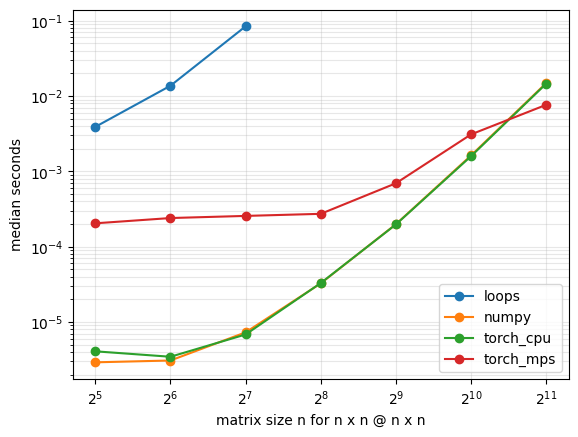

In [7]:
for engine in sorted({row["engine"] for row in results}):
    rows = [row for row in results if row["engine"] == engine]
    plt.plot([row["size"] for row in rows], [row["seconds"] for row in rows], marker="o", label=engine)

plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("matrix size n for n x n @ n x n")
plt.ylabel("median seconds")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [ ]:
"Question: Did your observed fastest-to-slowest ordering match your prediction? If not, what changed?"
"Answer: Mostly, but not much difference between numpy and torch_cpu"

"Question: Which implementation had the best constant factor in your benchmark, and what evidence supports that?"
"Answer: numpy, because it had the fastest perfomance on the smallest vector"

"Question: Where, if anywhere, did MPS start to beat PyTorch CPU on your machine? If it did not, what might explain that?"
"Answer: MPS didn't start to beat CPU until 2^11. At largest sizes the difference would have likely become larger"

"Question: Why does Python-loop matmul become unusable so quickly compared with NumPy and PyTorch?"
"Answer: Loops had to pay for python level overhead even at small size before vectorization would a major issue"

## Exercise 4 - Broadcasting predictions

Predict each result shape before running the verification cell. For valid cases, note which dimensions stretch.

In [9]:
broadcast_predictions = [
    ((3, 4), (4,), (3,4)),
    ((2, 1, 3), (1, 5, 1), (2,5,3)),
    ((5, 1), (1, 4), (5,4)),
    ((2, 3), (3, 2), "invalid"),
    ((), (2, 3, 4), (2,3,4)),
]

for shape_a, shape_b, predicted in broadcast_predictions:
    try:
        actual = broadcast_shapes(shape_a, shape_b)
    except ValueError:
        actual = "invalid"
    print(f"{shape_a} with {shape_b}: predicted={predicted}, actual={actual}")

(3, 4) with (4,): predicted=(3, 4), actual=(3, 4)
(2, 1, 3) with (1, 5, 1): predicted=(2, 5, 3), actual=(2, 5, 3)
(5, 1) with (1, 4): predicted=(5, 4), actual=(5, 4)
(2, 3) with (3, 2): predicted=invalid, actual=invalid
() with (2, 3, 4): predicted=(2, 3, 4), actual=(2, 3, 4)


In [10]:
example_a = TinyArray([1, 2, 3, 4, 5, 6], (2, 3))
example_b = TinyArray([10, 20, 30], (3,))

print("example_a shape:", example_a.shape)
print(example_a.to_nested())
print()
print("example_b shape:", example_b.shape)
print(example_b.to_nested())

example_a shape: (2, 3)
[[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]]

example_b shape: (3,)
[10.0, 20.0, 30.0]


In [11]:
"Question: What shape will example_a + example_b have, and which dimension broadcasts?"
"Answer: (2,3). Dimension 0 will broadcast"

"Question: What nested list do you expect from (example_a + example_b).to_nested()?"
"Answer: [[11, 22, 33], [14, 25, 36]"

# Uncomment after TinyArray broadcasting is implemented.
(example_a + example_b).to_nested()

[[11.0, 22.0, 33.0], [14.0, 25.0, 36.0]]

## Exercise 5 - Softmax stability

Implement a notebook-only naive softmax and run it on small and large logits. The naive version should overflow on the large logits; your real `g2c.tensors.softmax` should stay finite. Do not change the package implementation to make it fail.

In [12]:
def naive_softmax(x: torch.Tensor, dim: int = -1) -> torch.Tensor:
    e = torch.exp(x)
    return e / e.sum(dim=dim, keepdim=True)


small_logits = torch.tensor([1.0, 2.0, 3.0], dtype=torch.float32)
large_logits = torch.tensor([1000.0, 1001.0, 1002.0], dtype=torch.float32)

naive_small = naive_softmax(small_logits, dim=0)
naive_large = naive_softmax(large_logits, dim=0)
stable_large = softmax(large_logits, dim=0)
stable_shifted = softmax(large_logits + 123.0, dim=0)

print("naive small:", naive_small)
print("naive large:", naive_large)
print("stable large:", stable_large)
print("stable shifted:", stable_shifted)
print("stable is finite:", torch.isfinite(stable_large).all().item())
print("shift invariant:", torch.allclose(stable_large, stable_shifted, atol=1e-6))

naive small: tensor([0.0900, 0.2447, 0.6652])
naive large: tensor([nan, nan, nan])
stable large: tensor([0.0900, 0.2447, 0.6652])
stable shifted: tensor([0.0900, 0.2447, 0.6652])
stable is finite: True
shift invariant: True


In [13]:
"Question: What happened to naive_large, and why did it overflow?"
"Answer: Naive large overflowed because it hit 32 bit float limits"

"Question: Why does subtracting the max logit avoid overflow?"
"Answer: It makes sure that the sum doesn't exceed float limits"

"Question: Why does subtracting the same max value from every logit preserve the softmax probabilities?"
"Answer: Because it's a pure linear shift that goes into each value"


"Answer: Because it's a pure linear shift that goes into each value"

## Exercise 6 - Tiny classifier forward pass

Build a one-layer classifier with random weights. Predict the shape of each intermediate first, then run the forward pass and explain why each probability row should sum to 1.

In [23]:
batch = 4
in_features = 3
num_classes = 5

"Question: What shape should x have?"
"Answer: (4,3)"

"Question: What shape should W have under this module's x @ W + b convention?"
"Answer: (3,5)"

"Question: What shape should b have, and how does it broadcast?"
"Answer: (5,)"

"Question: What shape should logits have after linear(x, W, b)?"
"Answer: (5,4)"

"Question: What shape should probs have after softmax(logits, dim=-1)?"
"Answer: (5,4)"

"Question: Inside classifier_forward, which helper should produce logits, and which helper should turn logits into probabilities?"
"Answer: linear() produces logits and softmax() produces probs"


'Answer: linear() produces logits and softmax() produces probs'

In [24]:
def classifier_forward(
    x: torch.Tensor,
    W: torch.Tensor,
    b: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Return (logits, probs) for a one-layer classifier.

    Use this module's helpers:
      1. logits = linear(...)
      2. probs = softmax(..., dim=-1)
    """
    # TODO: compute logits with linear(x, W, b)
    # TODO: compute probs with softmax(logits, dim=-1)
    # TODO: return logits, probs
    logits = linear(x, W, b)
    probs = softmax(logits)
    return (logits, probs)

In [25]:
x = torch.randn(batch, in_features)
W = torch.randn(in_features, num_classes)
b = torch.zeros(num_classes)

logits, probs = classifier_forward(x, W, b)

shape_report = {
    "x": tuple(x.shape),
    "W": tuple(W.shape),
    "b": tuple(b.shape),
    "logits": tuple(logits.shape),
    "probs": tuple(probs.shape),
    "row_sums": probs.sum(dim=-1),
}

assert logits.shape == (batch, num_classes)
assert probs.shape == (batch, num_classes)
assert torch.allclose(probs.sum(dim=-1), torch.ones(batch), atol=1e-6)

shape_report

{'x': (4, 3),
 'W': (3, 5),
 'b': (5,),
 'logits': (4, 5),
 'probs': (4, 5),
 'row_sums': tensor([1.0000, 1.0000, 1.0000, 1.0000])}

In [ ]:
"Question: Did the observed shapes match your predictions? If not, what changed?"
"Answer: My initial guess for logits and probs was wrong, becuase I didn't consider the batch dimension on the output"

"Question: Why should each row of probs sum to 1? What does one row represent?"
"Answer: Because probability has to be normalized, otherwise it's not probability. Softmax does this by normalizing on the sum"

"Question: Why is there no training step in this module's classifier example?"
"Answer: "

## Submission Notes

When complete launch a coding agent like Codex or Claude and ask it to grade your exercise answers for Module 02. You can also use an agent to ask questions or grade partial answers.